In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [3]:
#load the dataset
file_path = "heart_disease.xlsx"

df = pd.read_excel(file_path, sheet_name="Heart_disease")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 908
Columns: 13


# EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [7]:
df.describe(include="object")

,sex,cp,restecg,exang,slope,thal
count,908,908,908,908,908,908
unique,2,4,3,4,3,3
top,Male,asymptomatic,normal,False,flat,reversable defect
freq,718,495,542,516,453,372


In [8]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [9]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [30]:
df["oldpeak"] = df["oldpeak"].fillna(df["oldpeak"].median())

In [31]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [32]:
 df.duplicated().sum()

np.int64(0)

In [33]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (907, 13)


In [34]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].unique())


 sex
['Male' 'Female']

 cp
['typical angina' 'atypical angina' 'asymptomatic' 'non-anginal']

 restecg
['lv hypertrophy' 'normal' 'st-t abnormality']

 slope
['downsloping' 'flat' 'upsloping']

 thal
['fixed defect' 'normal' 'reversable defect']


In [35]:
df["exang"] = df["exang"].replace({
    "TURE": True,
    "TRUE": True,
    "FALSE": False
})

In [36]:
print(df["exang"].unique())

[False  True]


In [37]:
target = "num"

In [38]:
print(df["num"].value_counts().sort_index())

num
0    399
1    265
2    108
3    107
4     28
Name: count, dtype: int64


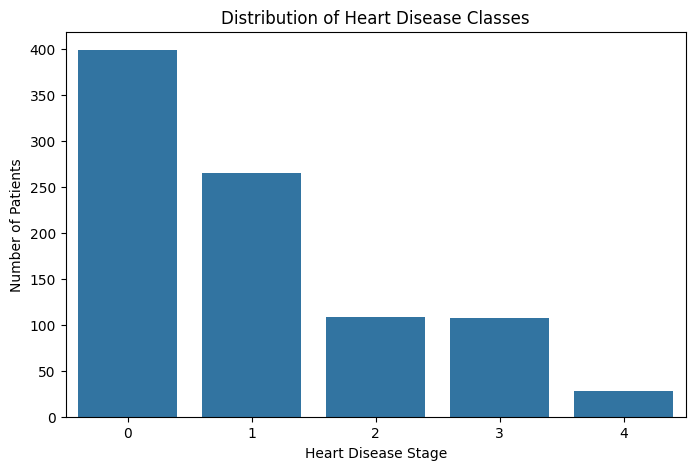

In [39]:

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="num")

plt.title("Distribution of Heart Disease Classes")
plt.xlabel("Heart Disease Stage")
plt.ylabel("Number of Patients")

plt.show()

In [40]:
numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns)

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')


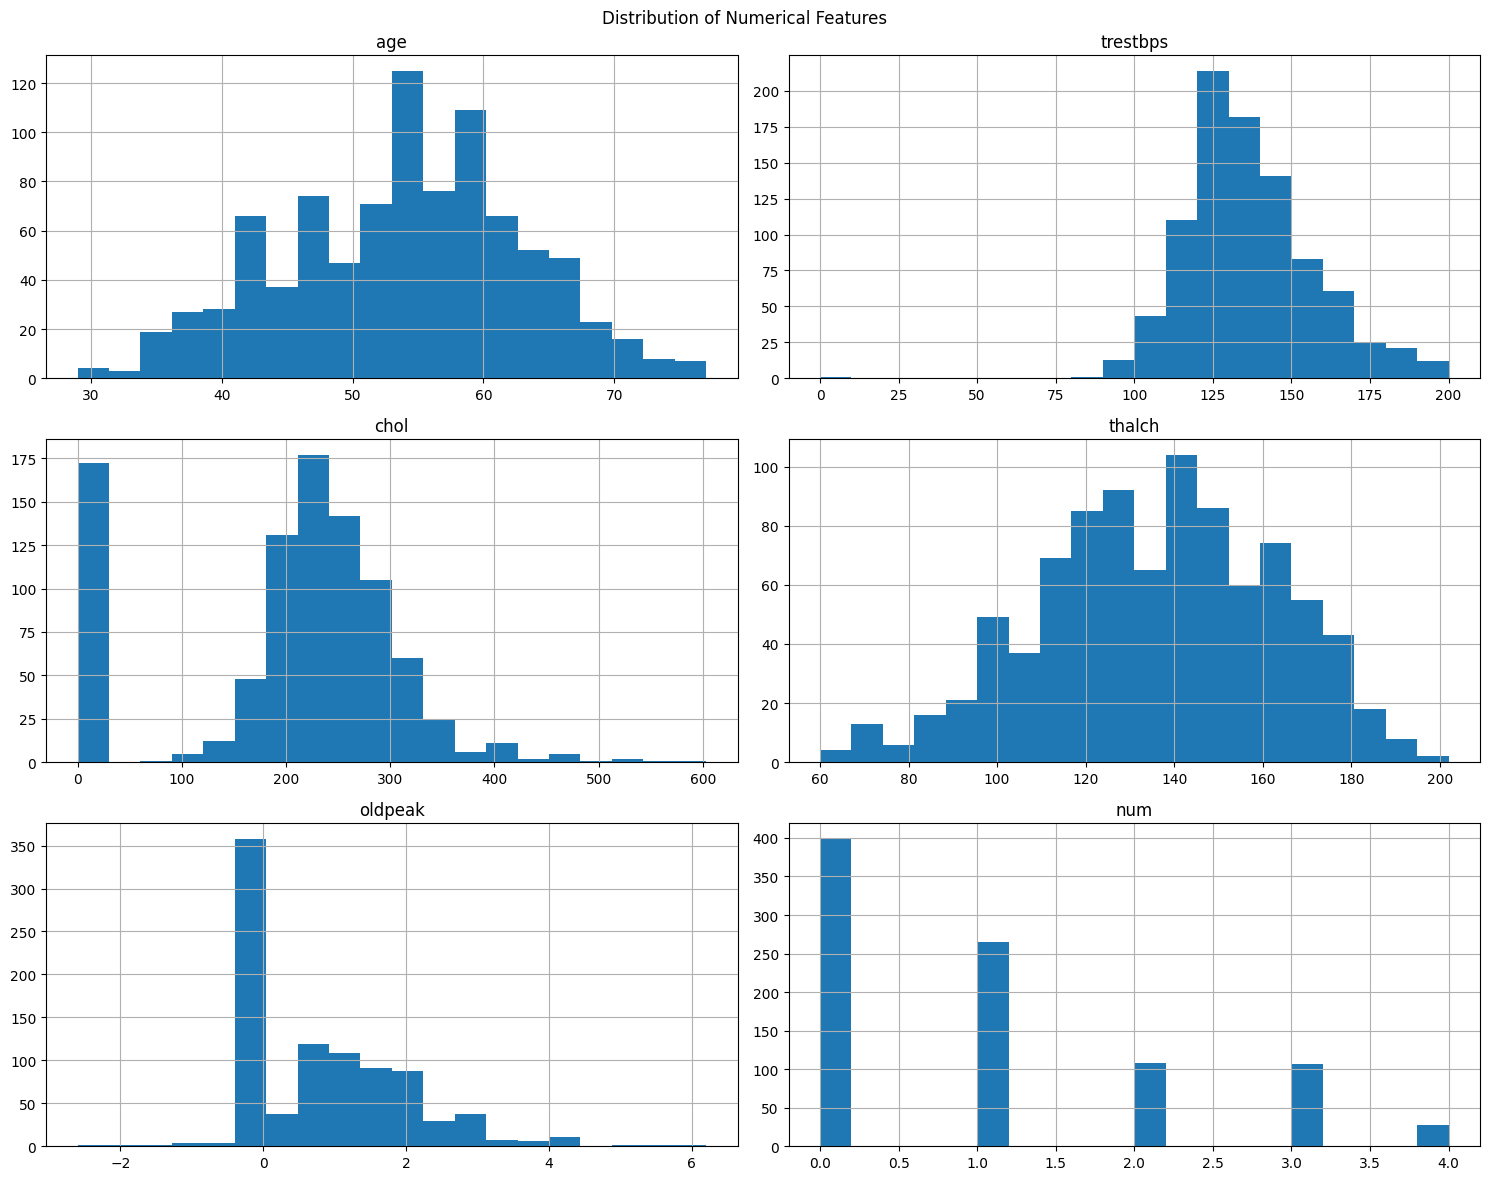

In [41]:
#histogram
df[numerical_columns].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")

plt.tight_layout()
plt.show()

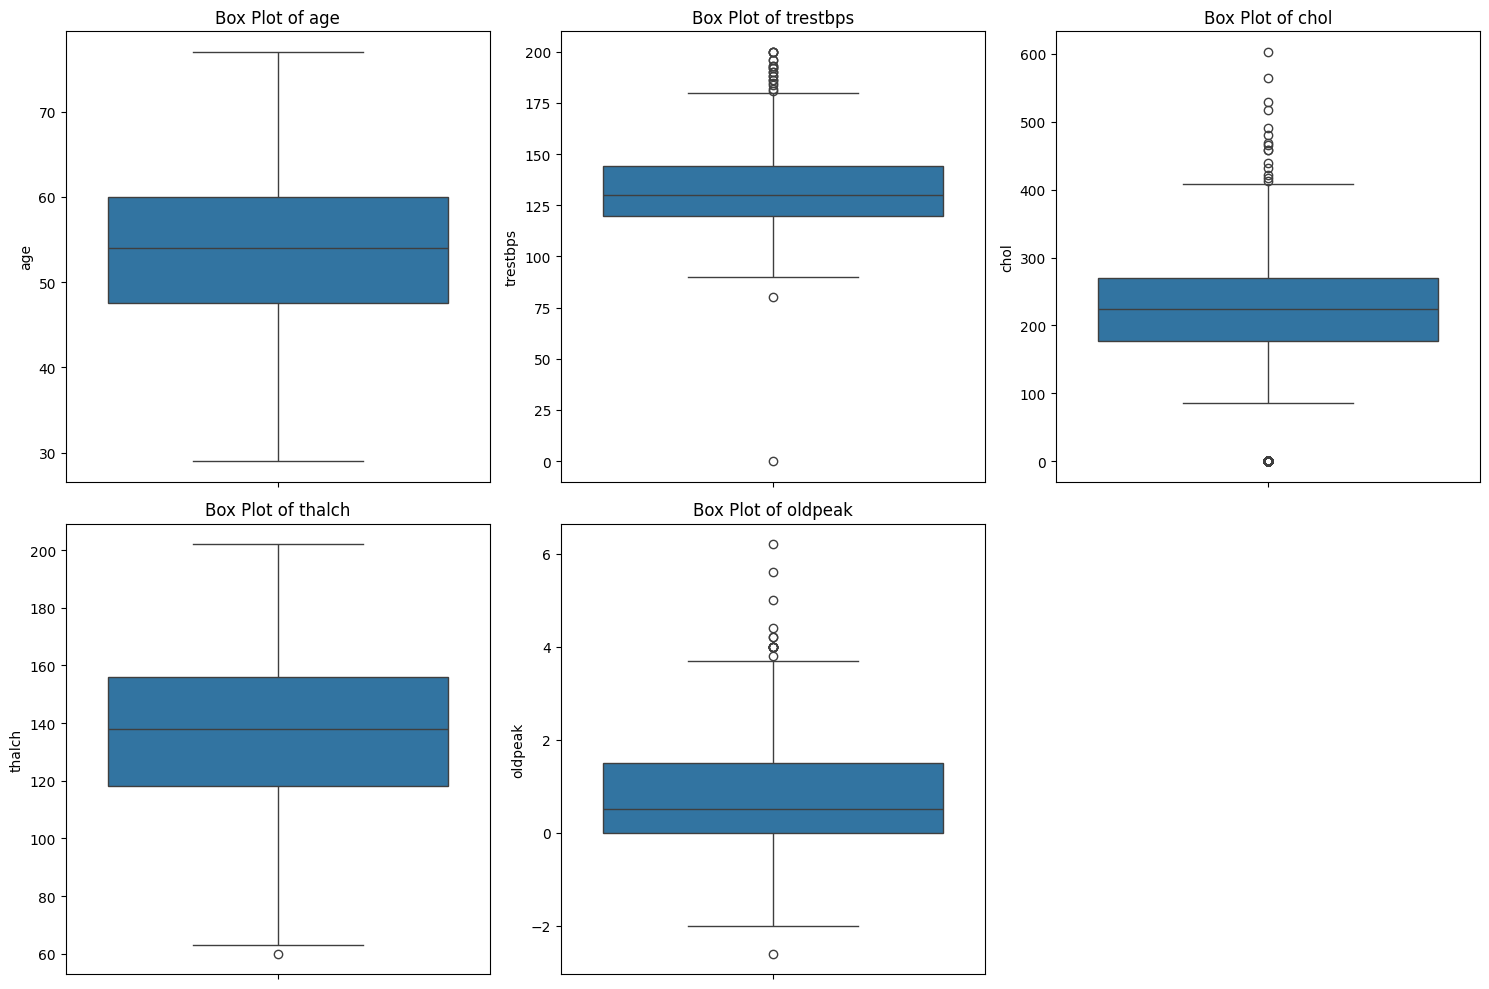

In [42]:
#boxplot
plt.figure(figsize=(15, 10))

for i, col in enumerate(
    ["age", "trestbps", "chol", "thalch", "oldpeak"],
    1
):
    plt.subplot(2, 3, i)

    sns.boxplot(y=df[col])

    plt.title(f"Box Plot of {col}")

plt.tight_layout()
plt.show()

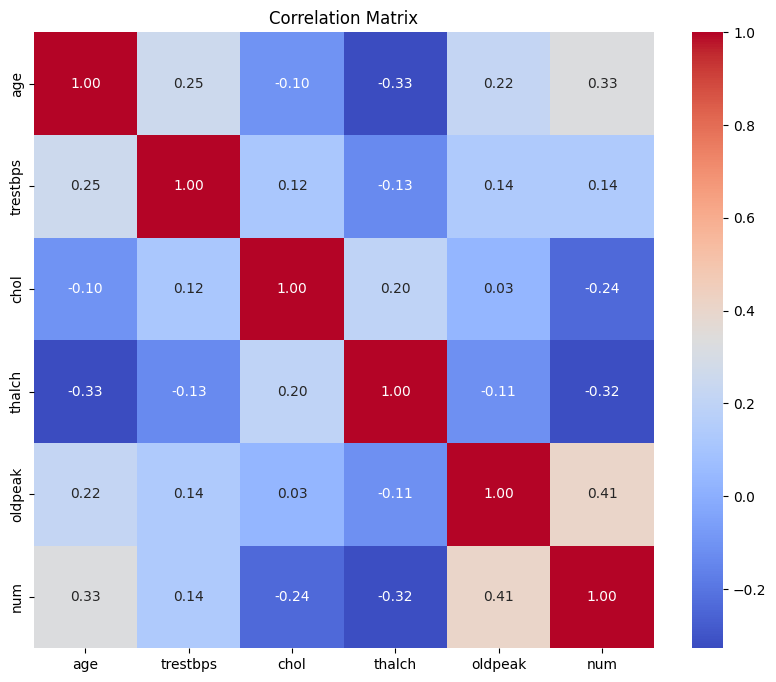

In [43]:
#correlation matrix
plt.figure(figsize=(10, 8))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# Feature engineering

In [44]:
X = df.drop("num", axis=1)
y = df["num"]

In [45]:
print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  
0  False      2.3  downsloping  fixed defect  
1  False      0.0         flat  fixed defect  
2  False      0.4         flat  fixed defect  
3  False      0.0         flat  fixed defect  
4   True      1.5         flat  fixed defect  

Target:
0    0
1    0
2    0
3    0
4    0
Name: num, dtype: int64


In [46]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (725, 12)
Testing data: (182, 12)


In [47]:
#preprocessing pipeline
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

In [48]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

#  Decision Tree Classification:

In [55]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", decision_tree)
    ]
)
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[1 2 1 3 1 2 0 1 1 0 0 0 2 2 2 1 0 2 1 1]


In [57]:
#evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.43956043956043955


In [60]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Precision:", precision)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Recall:", recall)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("F1 Score:", f1)


y_probability = model.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_probability,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC:", roc_auc)

Precision: 0.46389106924821216
Recall: 0.43956043956043955
F1 Score: 0.4505354230511159
ROC-AUC: 0.621168224965324


In [62]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.74      0.66      0.70        80
           1       0.34      0.36      0.35        53
           2       0.11      0.14      0.12        22
           3       0.19      0.19      0.19        21
           4       0.20      0.17      0.18         6

    accuracy                           0.44       182
   macro avg       0.31      0.30      0.31       182
weighted avg       0.46      0.44      0.45       182



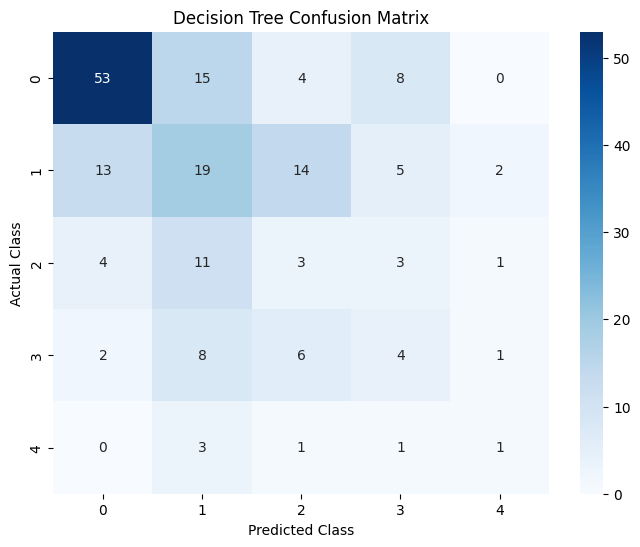

In [63]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

# Hyperparameter Tuning:

In [66]:
parameter_grid = {
    "classifier__criterion": [
        "gini",
        "entropy",
        "log_loss"
    ],

    "classifier__max_depth": [
        3,
        5,
        7,
        10,
        None
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10
    ]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=parameter_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__criterion': ['gini', 'entropy', ...], 'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_split': [2, 5, ...]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [67]:
#Best Hyperparameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_split': 10}


In [68]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

y_probability_tuned = best_model.predict_proba(X_test)

# . Model Evaluation and Analysis:

In [72]:
#evaluate the tuned model
print("Tuned Decision Tree Performance")
print("--------------------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_tuned)
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_tuned,
        average="weighted",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_tuned,
        average="weighted",
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred_tuned,
        average="weighted",
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_probability_tuned,
        multi_class="ovr",
        average="weighted"
    )
)

Tuned Decision Tree Performance
--------------------------------
Accuracy: 0.5274725274725275
Precision: 0.5311971978638644
Recall: 0.5274725274725275
F1 Score: 0.5138775292243829
ROC-AUC: 0.7173007644665549


In [73]:
#classification on tuned model
print(
    classification_report(
        y_test,
        y_pred_tuned,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.79      0.71      0.75        80
           1       0.38      0.58      0.46        53
           2       0.33      0.09      0.14        22
           3       0.27      0.29      0.28        21
           4       0.00      0.00      0.00         6

    accuracy                           0.53       182
   macro avg       0.36      0.33      0.33       182
weighted avg       0.53      0.53      0.51       182



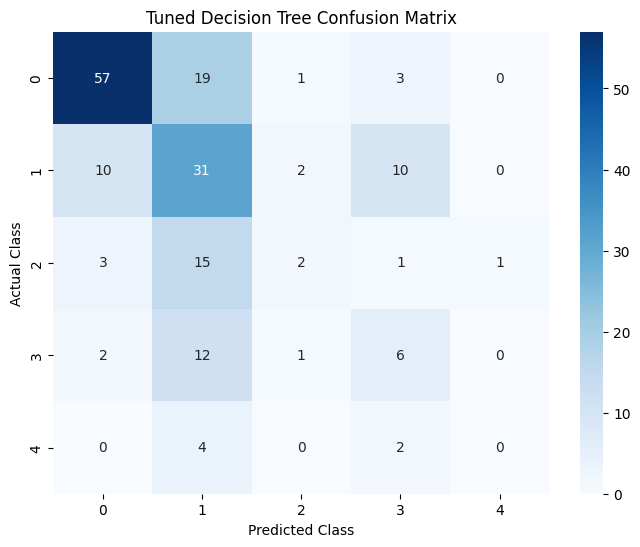

In [74]:
#confusion on tuned model
cm = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Decision Tree Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [76]:
#visualize the decision tree
X_train_transformed = (
    best_model
    .named_steps["preprocessor"]
    .transform(X_train)
)
feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)
tree_model = (
    best_model
    .named_steps["classifier"]
)

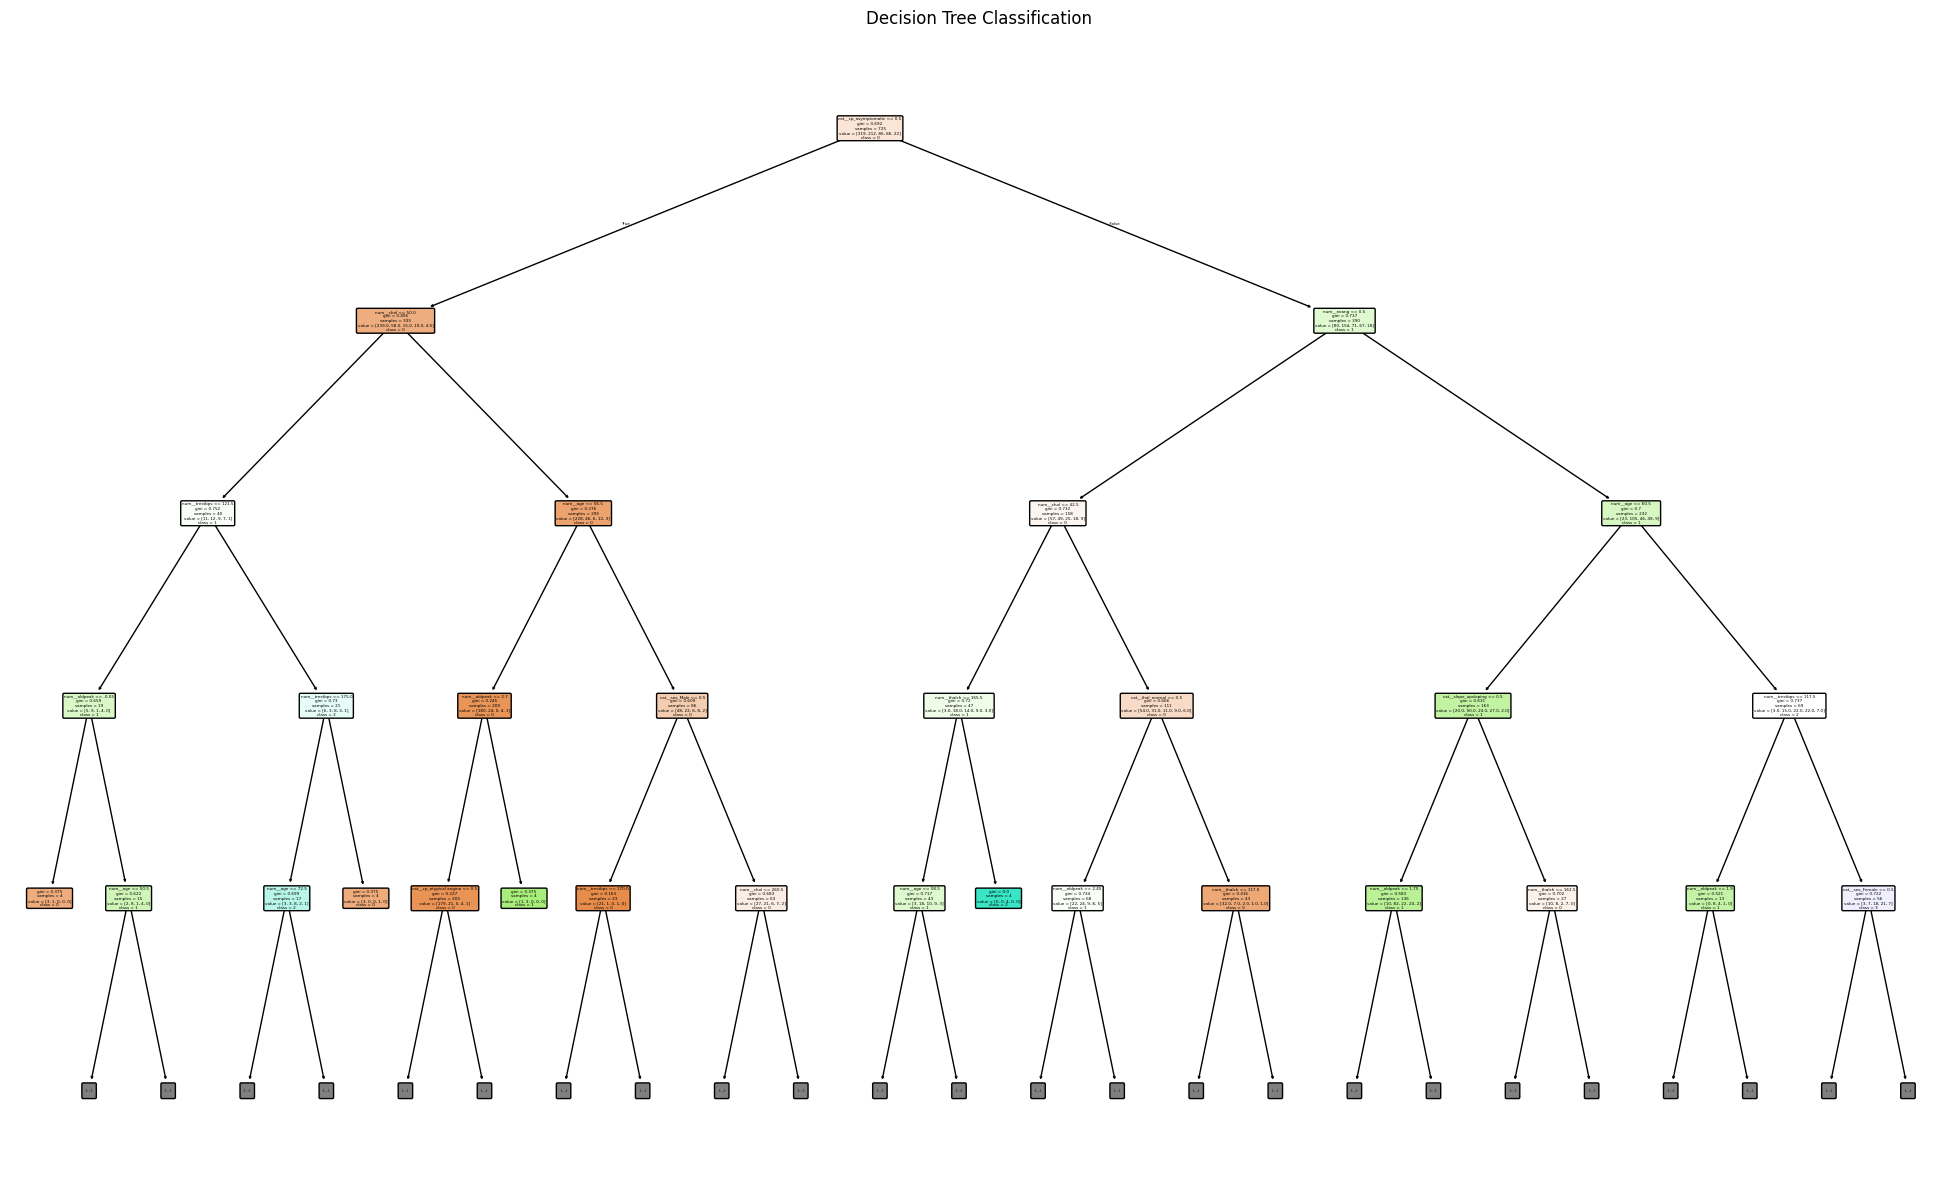

In [77]:
plt.figure(figsize=(25, 15))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=[
        str(c) for c in sorted(y.unique())
    ],
    filled=True,
    rounded=True,
    max_depth=4
)

plt.title("Decision Tree Classification")

plt.show()

In [80]:
#feature importance in the decision tree
importance = tree_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                          Feature  Importance
9            cat__cp_asymptomatic    0.361696
2                       num__chol    0.140069
0                        num__age    0.130867
6                    num__oldpeak    0.083187
1                   num__trestbps    0.057087
5                      num__exang    0.055431
4                     num__thalch    0.040934
20               cat__thal_normal    0.035980
8                   cat__sex_Male    0.033081
18           cat__slope_upsloping    0.026885
7                 cat__sex_Female    0.020072
10        cat__cp_atypical angina    0.014710
3                        num__fbs    0.000000
11            cat__cp_non-anginal    0.000000
13    cat__restecg_lv hypertrophy    0.000000
12         cat__cp_typical angina    0.000000
14            cat__restecg_normal    0.000000
15  cat__restecg_st-t abnormality    0.000000
17                cat__slope_flat    0.000000
16         cat__slope_downsloping    0.000000
19         cat__thal_fixed defect 

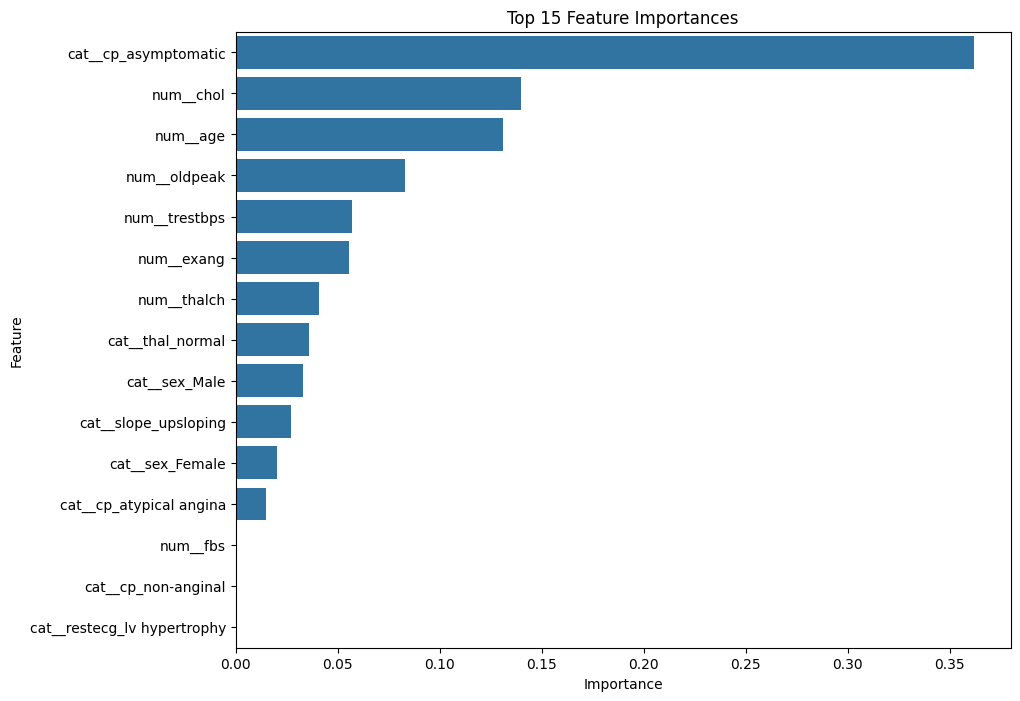

In [81]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")

plt.show()

# Interview Questions

#### 1. What are common hyperparameters of Decision Trees?

Common Decision Tree hyperparameters include max_depth, min_samples_split, min_samples_leaf, criterion, and max_features. They control tree complexity and therefore influence the balance between underfitting and overfitting. Increasing restrictions such as lowering max_depth or increasing min_samples_leaf generally produces a simpler model, while allowing deeper trees can increase model complexity and potentially cause overfitting.


#### 2. What is the difference between the Label encoding and One-hot encoding?

Label encoding replaces categories with numerical labels such as 0, 1, and 2. It is appropriate when categories have an inherent order, such as Low, Medium, and High. One-hot encoding creates separate binary columns for each category and is generally preferred for nominal categorical variables because it does not introduce an artificial numerical relationship between categories